In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from utils import bs_call, bs_put, monte_carlo_european_options
from quantum_pricing_utils import price_Eurocall, price_Europut

In [2]:
S0 = 100
K = 100
r = 0.045
sigma = 0.25
T = 1.0

c = 0.25
n_qubits = 3

# Test put-call parity

In [ ]:
S = np.linspace(60, 180, 25)

In [5]:
quantum_forward, forward = [], []
error, rel_error = [], []

for s in S : 
    call = price_Eurocall(s, K, r, sigma, T, n_qubits, c)
    put = price_Europut(s, K, r, sigma, T, n_qubits, c)

    F = s - K*np.exp(-r*T)

    q_F = call - put 

    e = abs(F - q_F)
    if F != 0 :
        rel_e = e/abs(F)
        rel_error.append(rel_e)

    quantum_forward.append(q_F)
    forward.append(F)
    error.append(e) 

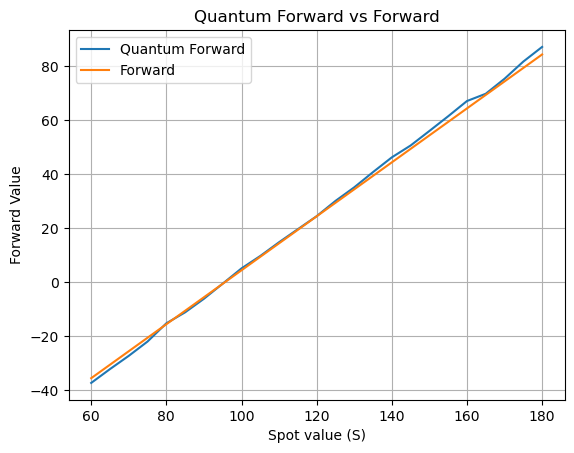

In [6]:
plt.figure()
plt.plot(S, quantum_forward, label="Quantum Forward")
plt.plot(S, forward, label="Forward")

plt.xlabel("Spot value (S)")
plt.ylabel("Forward Value")
plt.title("Quantum Forward vs Forward")
plt.legend()
plt.grid(True)

plt.show()

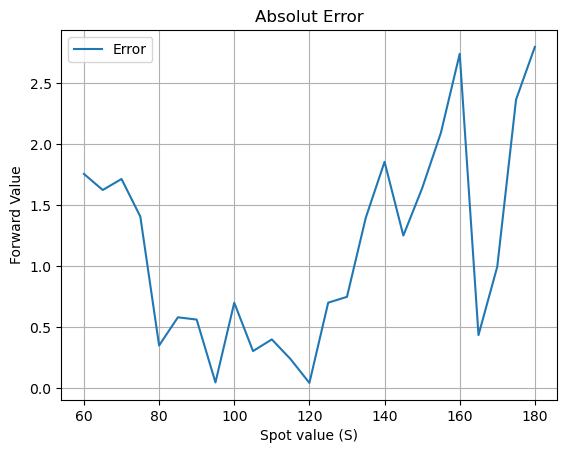

In [7]:
plt.figure()
plt.plot(S, error, label="Error")

plt.xlabel("Spot value (S)")
plt.ylabel("Forward Value")
plt.title("Absolut Error")
plt.legend()
plt.grid(True)

plt.show()

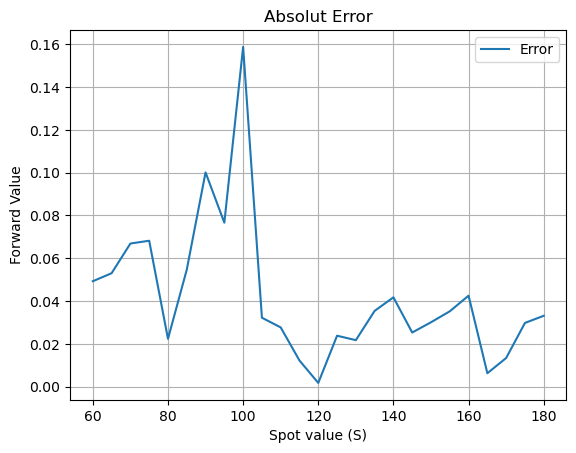

In [8]:
plt.figure()
plt.plot(S, rel_error, label="Error")

plt.xlabel("Spot value (S)")
plt.ylabel("Forward Value")
plt.title("Absolut Error")
plt.legend()
plt.grid(True)

plt.show()

# Study of the error 

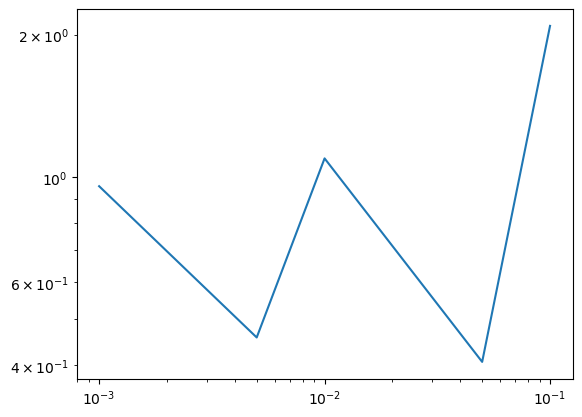

In [9]:
epsilon = [0.1, 0.05, 0.01, 0.005, 0.001]
errors = []

for e in epsilon : 
    
    q_call = price_Eurocall(S0, K, r, sigma, T, n_qubits, c, e)
    call = bs_call(S0, K, sigma, r, T)

    errors.append(abs(call - q_call))

plt.loglog(epsilon, errors)

# Monte-Carlo convergence

In [10]:
n_paths_list = [100, 500, 1000, 5000, 10000, 50000]
mc_errors = []

for n in n_paths_list : 
    results = monte_carlo_european_options(S0, K, r, T, sigma, n, 252)
    call_mc = results['call_price']
    call_bs = bs_call(S0, K, sigma, r, T)

    mc_errors.append(abs(call_mc - call_bs))


In [16]:
epsilon_list = [0.1, 0.05, 0.02, 0.01, 0.005, 0.001, 0.0001]
qae_errors, qae_calls = [], []
for eps in epsilon_list:
    q_call = price_Eurocall(S0, K, r, sigma, T, n_qubits, c, eps)
    call_bs = bs_call(S0, K, sigma, r, T)
    qae_calls.append(q_call)
    qae_errors.append(abs(q_call - call_bs))

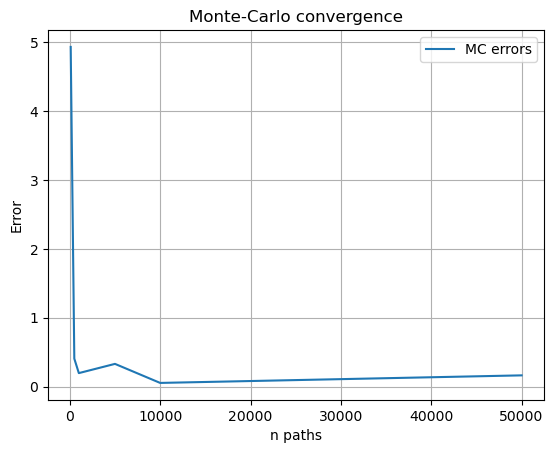

In [12]:
plt.figure()
plt.plot(n_paths_list, mc_errors, label="MC errors")

plt.xlabel("n paths")
plt.ylabel("Error")
plt.title("Monte-Carlo convergence")
plt.legend()
plt.grid(True)

plt.show()

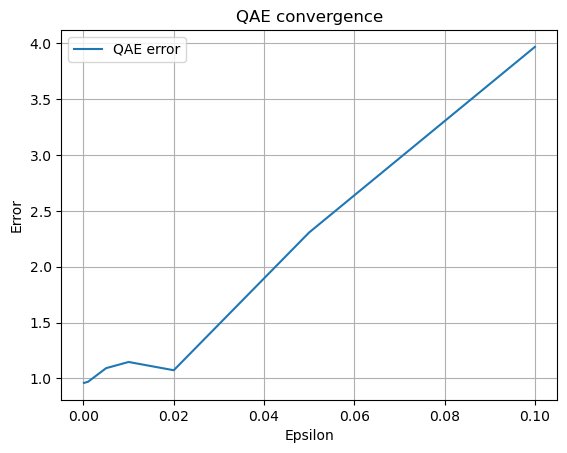

In [17]:
plt.figure()
plt.plot(epsilon_list, qae_errors, label="QAE error")

plt.xlabel("Epsilon")
plt.ylabel("Error")
plt.title("QAE convergence")
plt.legend()
plt.grid(True)

plt.show()

# Test effet de discretisation

In [3]:
qbits = [2, 3, 4, 5, 6, 7, 8]
error = []

for n in qbits:
    q_call = price_Eurocall(S0, K, r, sigma, T, n, c)
    call_bs = bs_call(S0, K, sigma, r, T)

    error.append(abs(q_call - call_bs))

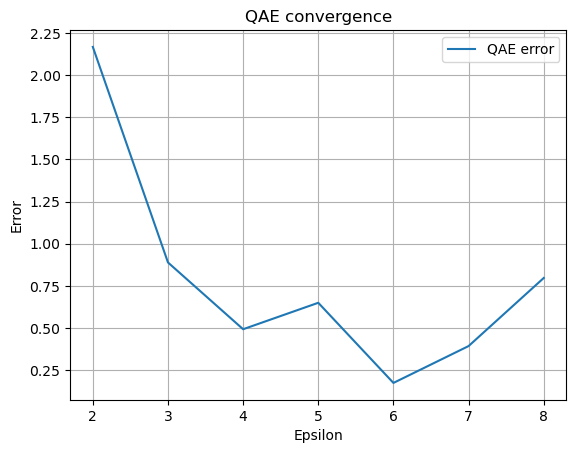

In [4]:
plt.figure()
plt.plot(qbits, error, label="QAE error")

plt.xlabel("Epsilon")
plt.ylabel("Error")
plt.title("QAE convergence")
plt.legend()
plt.grid(True)

plt.show()